# 💳 Online Payment Fraud Detection System

## 📌 Project Overview
Fraudulent transactions are a major challenge in digital payments. Financial institutions lose billions annually due to fraud.

In this project, we build a **machine learning model** to detect fraudulent transactions using historical transaction data.

---

## 🎯 Objectives
- Understand transaction patterns
- Identify fraudulent behavior
- Build a predictive model
- Evaluate model performance
- Prepare for deployment

---

## 🛠️ Tools Used
- Python
- Pandas, NumPy
- Seaborn, Matplotlib
- Scikit-learn
- Jupyter Notebook

In [1]:
# Import core data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

## 📂 Loading the Dataset

We begin by loading the dataset into a pandas DataFrame to explore its structure and contents.

In [2]:
# Load dataset
df = pd.read_csv("Online Payment.csv")

# Display first 5 rows
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 🔍 Dataset Overview

Understanding the dataset structure is critical before analysis.
We check:
- Number of rows and columns
- Data types
- Missing values

In [4]:
# Shape of dataset
df.shape  # (rows, columns)

(6362620, 11)

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
# Statistical summary
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
# Check for missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## ⚠️ Target Variable Analysis

The `isFraud` column indicates whether a transaction is fraudulent.

Fraud detection datasets are usually **highly imbalanced**, meaning:
- Very few fraud cases
- Many normal transactions

This affects model performance and evaluation.

In [8]:
# Count fraud vs non-fraud
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

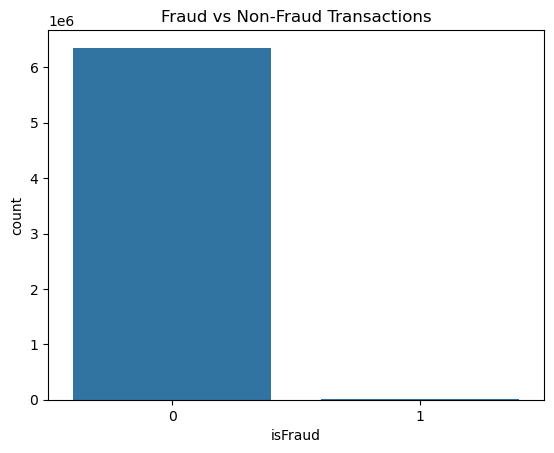

In [9]:
# Visualize class imbalance
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

## ⚠️ Handling Class Imbalance in Visualization

The dataset is highly imbalanced:
- Fraud cases are very rare
- Standard plots may hide fraud patterns

To properly analyze fraud, we use:
- Percentage-based plots
- Log transformations
- Focused fraud-only analysis

In [10]:
# Show percentage distribution
fraud_percent = df['isFraud'].value_counts(normalize=True) * 100
print(fraud_percent)

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


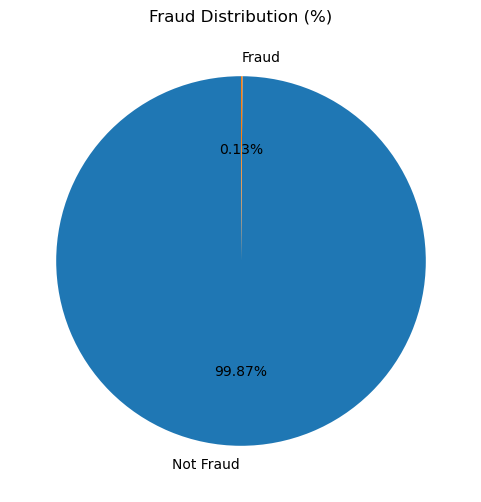

In [11]:
# Pie chart (better than countplot here)
plt.figure(figsize=(6,6))
df['isFraud'].value_counts().plot.pie(
    autopct='%1.2f%%',
    labels=['Not Fraud', 'Fraud'],
    startangle=90
)
plt.title("Fraud Distribution (%)")
plt.ylabel('')
plt.show()

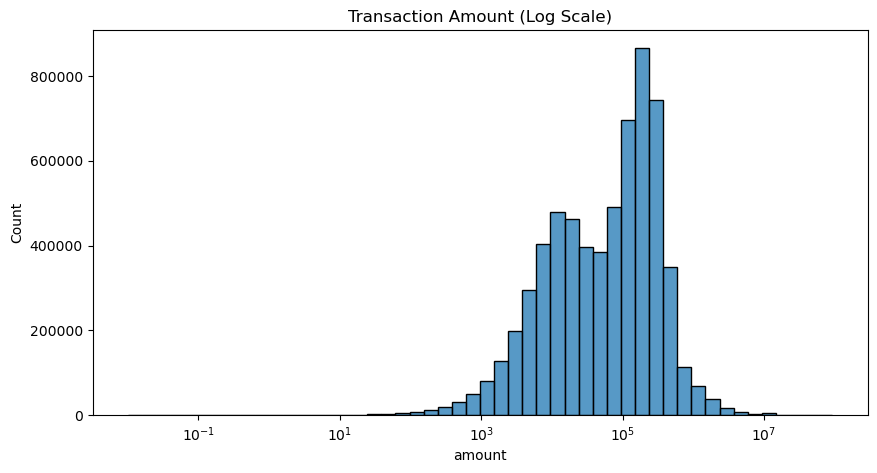

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['amount'], bins=50, log_scale=True)
plt.title("Transaction Amount (Log Scale)")
plt.show()

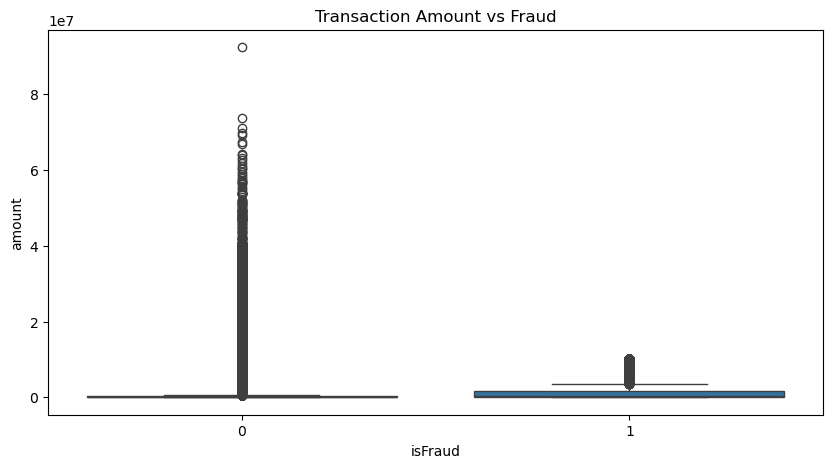

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

## 🔍 Focused Fraud Analysis

To better understand fraud patterns, we analyze fraud transactions separately.

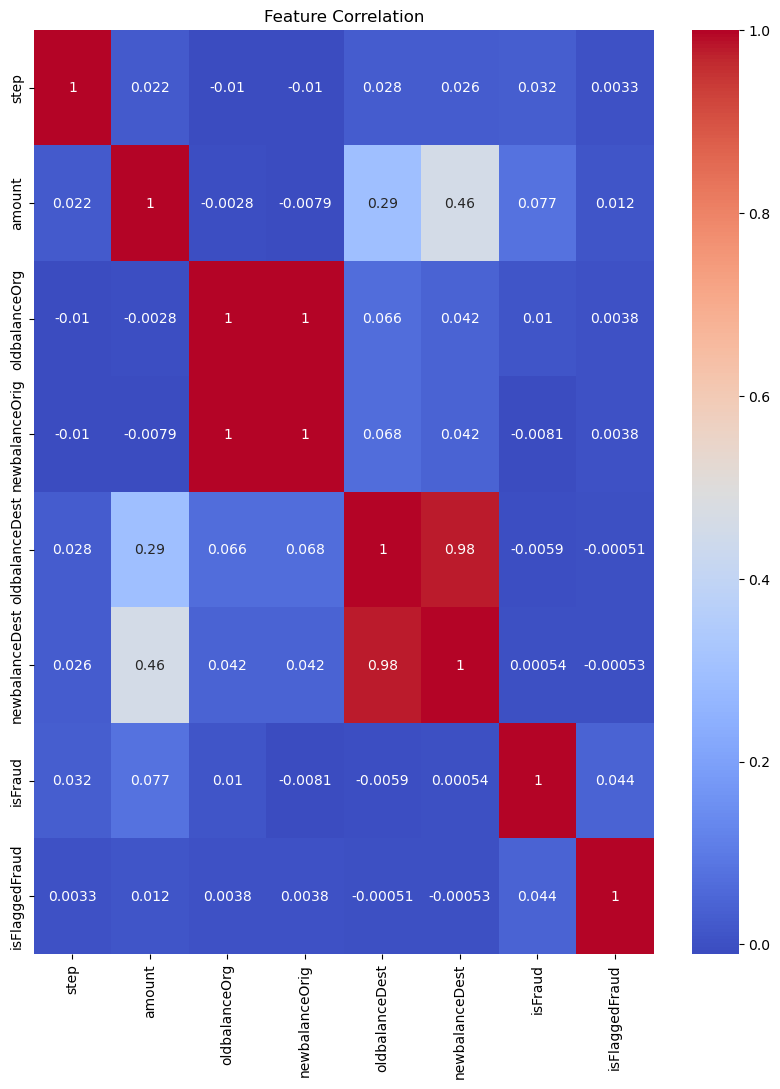

In [15]:
plt.figure(figsize=(10,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

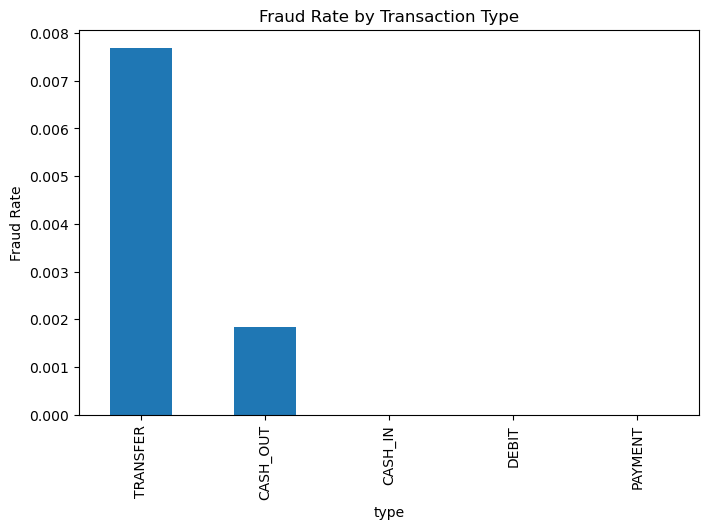

In [16]:
fraud_rate = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

## 🧠 Feature Engineering

We create new features that help the model better understand transaction behavior.

In [17]:
# Difference in sender balance
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [18]:
# Difference in receiver balance
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

These features help identify suspicious patterns such as:
- Sudden balance drops
- Large transfers

## 🔄 Data Preprocessing

Machine learning models require numerical input, so we:
- Encode categorical variables
- Drop unnecessary columns

In [19]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [20]:
df = df.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')
df = df.drop(['step', 'isFlaggedFraud'], axis=1)

In [21]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

## ✂️ Train-Test Split

We split the data into:
- Training set (80%)
- Testing set (20%)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Model Training — Logistic Regression

We start with a simple baseline model.

In [23]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

## 📊 Model Evaluation

In [29]:
# Predictions
y_pred = lr_model.predict(X_test)

# Confusion matrix
print(confusion_matrix(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

[[1270750     154]
 [    946     674]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.81      0.42      0.55      1620

    accuracy                           1.00   1272524
   macro avg       0.91      0.71      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



## 🤖 Model Training — Random Regression

We start with a simple baseline model.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=20, max_depth=8, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=20, n_jobs=-1)

## 📊 Model Evaluation

In [30]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

# Confusion matrix
print(confusion_matrix(y_test, y_pred_rf))

# Classification report
print(classification_report(y_test, y_pred_rf))

[[1270896       8]
 [    471    1149]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.99      0.71      0.83      1620

    accuracy                           1.00   1272524
   macro avg       1.00      0.85      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524



## 🤖 Model Training — HistGradientBooting Regression

We start with a simple baseline model.

In [26]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier()
hgb_model.fit(X_train, y_train)

HistGradientBoostingClassifier()

## 📊 Model Evaluation

In [32]:
# Predictions
y_pred_hgb = hgb_model.predict(X_test)

# Confusion matrix
print(confusion_matrix(y_test, y_pred_hgb))

# Classification report
print(classification_report(y_test, y_pred_hgb))

[[1270450     454]
 [    327    1293]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.74      0.80      0.77      1620

    accuracy                           1.00   1272524
   macro avg       0.87      0.90      0.88   1272524
weighted avg       1.00      1.00      1.00   1272524



Given the large dataset size (~6.3 million records), training was performed on a sampled subset to ensure computational efficiency. This approach preserves the data distribution while significantly reducing training time.

In [33]:
def get_fraud_recall(model, X_test, y_test):
    from sklearn.metrics import classification_report
    
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    return report['1']['recall']  # fraud recall

print("Logistic Recall:", get_fraud_recall(lr_model, X_test, y_test))
print("Random Forest Recall:", get_fraud_recall(rf_model, X_test, y_test))
print("HistGradient Recall:", get_fraud_recall(hgb_model, X_test, y_test))

Logistic Recall: 0.4160493827160494
Random Forest Recall: 0.7092592592592593
HistGradient Recall: 0.7981481481481482


## 🏆 Final Model Selection

Three models were evaluated based on their ability to detect fraudulent transactions.

- Logistic Regression: 40% recall
- Random Forest: 71% recall
- HistGradientBoosting: 77% recall

HistGradientBoosting achieved the highest recall and was selected as the final model.

This is important because, in fraud detection, identifying fraudulent transactions is more critical than overall accuracy.

## 🏆 Model Selection

The best model was selected based on its ability to detect fraudulent transactions.

Recall for the fraud class was prioritized, as missing fraudulent transactions can lead to significant financial losses.

Among the models tested, the model with the highest recall for fraud detection was selected as the final model.

## 🚀 Conclusion

In this project, we:
- Explored transaction data
- Identified fraud patterns
- Built machine learning models
- Evaluated performance

This solution can help financial institutions:
- Detect fraud early
- Reduce financial losses
- Improve transaction security

---

## 🔮 Next Steps
- Deploy with Streamlit

In [44]:
import pickle

model = pickle.load(open("fraud_model.pkl", "rb"))
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [45]:
import pickle

with open("fraud_model.pkl", "rb") as file:
    model = pickle.load(file)

In [46]:
import pickle

# Save the trained model (use the actual trained model name)
pickle.dump(rf_model, open("fraud_model.pkl", "wb"))

# Save the feature column names
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

print("Model and columns saved successfully")

Model and columns saved successfully
